In [1]:
# Day 2 - Pandas: The SQL engineer's best friend
# Everything you do in SQL, Pandas does in Python

import pandas as pd
import numpy as np

# Read the CSV you created yesterday
# Tomorrow this will be a real Kaggle dataset
df = pd.read_csv("employees.csv")

# Your new DESC TABLE
print(df.info())
print("---")
1
# Your new SELECT * LIMIT 5
print(df.head())
print("---")

# Quick stats — like running COUNT, AVG, MIN, MAX all at once
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    5 non-null      object
 1   city    5 non-null      object
 2   salary  5 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 252.0+ bytes
None
---
    name     city  salary
0    Sam  Chennai   45000
1  Priya   Mumbai   72000
2    Raj  Chennai   58000
3  Anita    Delhi   91000
4  Kiran  Chennai   63000
---
             salary
count      5.000000
mean   65800.000000
std    17137.677789
min    45000.000000
25%    58000.000000
50%    63000.000000
75%    72000.000000
max    91000.000000


In [2]:
# Day 2 - SELECT and WHERE in Pandas

# SELECT name FROM employees
print(df["name"])
print("---")

# SELECT name, salary FROM employees
print(df[["name", "salary"]])
print("---")

# SELECT * FROM employees WHERE city = 'Chennai'
chennai = df[df["city"] == "Chennai"]
print(chennai)
print("---")

# SELECT * FROM employees WHERE salary > 60000
high_earners = df[df["salary"] > 60000]
print(high_earners)
print("---")

# SELECT * FROM employees WHERE city = 'Chennai' AND salary > 50000
result = df[(df["city"] == "Chennai") & (df["salary"] > 50000)]
print(result)

0      Sam
1    Priya
2      Raj
3    Anita
4    Kiran
Name: name, dtype: object
---
    name  salary
0    Sam   45000
1  Priya   72000
2    Raj   58000
3  Anita   91000
4  Kiran   63000
---
    name     city  salary
0    Sam  Chennai   45000
2    Raj  Chennai   58000
4  Kiran  Chennai   63000
---
    name     city  salary
1  Priya   Mumbai   72000
3  Anita    Delhi   91000
4  Kiran  Chennai   63000
---
    name     city  salary
2    Raj  Chennai   58000
4  Kiran  Chennai   63000


In [3]:
# Day 2 - GROUP BY and JOIN in Pandas

# GROUP BY city, COUNT(*), AVG(salary), SUM(salary)
summary = df.groupby("city").agg(
    employee_count=("name", "count"),
    avg_salary=("salary", "mean"),
    total_salary=("salary", "sum"),
    max_salary=("salary", "max")
).reset_index()

print("GROUP BY city:")
print(summary)
print("---")

# Create a second table to JOIN with
# Like a departments table in SQL
departments = pd.DataFrame({
    "city": ["Chennai", "Mumbai", "Delhi"],
    "office": ["South HQ", "West HQ", "North HQ"],
    "team_size": [50, 30, 20]
})

print("Departments table:")
print(departments)
print("---")

# LEFT JOIN employees ON city = city
merged = df.merge(departments, on="city", how="left")
print("After LEFT JOIN:")
print(merged)

GROUP BY city:
      city  employee_count    avg_salary  total_salary  max_salary
0  Chennai               3  55333.333333        166000       63000
1    Delhi               1  91000.000000         91000       91000
2   Mumbai               1  72000.000000         72000       72000
---
Departments table:
      city    office  team_size
0  Chennai  South HQ         50
1   Mumbai   West HQ         30
2    Delhi  North HQ         20
---
After LEFT JOIN:
    name     city  salary    office  team_size
0    Sam  Chennai   45000  South HQ         50
1  Priya   Mumbai   72000   West HQ         30
2    Raj  Chennai   58000  South HQ         50
3  Anita    Delhi   91000  North HQ         20
4  Kiran  Chennai   63000  South HQ         50


In [4]:
# Day 2 - CASE WHEN and derived columns in Pandas

# CASE WHEN salary > 80000 THEN 'Senior' in Pandas = apply + lambda
df["level"] = df["salary"].apply(lambda x: 
    "Senior" if x > 80000 
    else "Mid" if x > 55000 
    else "Junior"
)

# New derived column — like SELECT salary * 1.10 AS new_salary
df["salary_after_raise"] = df["salary"] * 1.10

# Another derived column — salary in lakhs
df["salary_lakhs"] = (df["salary"] / 100000).round(2)

print(df)
print("---")

# ORDER BY salary DESC
print(df.sort_values("salary", ascending=False))
print("---")

# SELECT TOP 3 — LIMIT 3
print(df.nlargest(3, "salary")[["name", "salary", "level"]])

    name     city  salary   level  salary_after_raise  salary_lakhs
0    Sam  Chennai   45000  Junior             49500.0          0.45
1  Priya   Mumbai   72000     Mid             79200.0          0.72
2    Raj  Chennai   58000     Mid             63800.0          0.58
3  Anita    Delhi   91000  Senior            100100.0          0.91
4  Kiran  Chennai   63000     Mid             69300.0          0.63
---
    name     city  salary   level  salary_after_raise  salary_lakhs
3  Anita    Delhi   91000  Senior            100100.0          0.91
1  Priya   Mumbai   72000     Mid             79200.0          0.72
4  Kiran  Chennai   63000     Mid             69300.0          0.63
2    Raj  Chennai   58000     Mid             63800.0          0.58
0    Sam  Chennai   45000  Junior             49500.0          0.45
---
    name  salary   level
3  Anita   91000  Senior
1  Priya   72000     Mid
4  Kiran   63000     Mid


In [5]:
# Day 2 - NULL handling in Pandas
# Real datasets are always messy — this is IS NULL, COALESCE, DROP

# Create a messy dataset with nulls
messy = pd.DataFrame({
    "name":   ["Sam", "Priya", None, "Anita", "Kiran"],
    "city":   ["Chennai", None, "Delhi", "Mumbai", "Chennai"],
    "salary": [45000, 72000, None, 91000, None]
})

print("Original messy data:")
print(messy)
print("---")

# IS NULL — find nulls
print("Null counts:")
print(messy.isna().sum())
print("---")

# COALESCE — fill nulls with a default value
messy["city"] = messy["city"].fillna("Unknown")
messy["salary"] = messy["salary"].fillna(messy["salary"].mean())
messy["name"] = messy["name"].fillna("Anonymous")

print("After filling nulls:")
print(messy)
print("---")

# Drop rows where ANY column is still null
clean = messy.dropna()
print(f"Rows after dropna: {len(clean)}")

Original messy data:
    name     city   salary
0    Sam  Chennai  45000.0
1  Priya     None  72000.0
2   None    Delhi      NaN
3  Anita   Mumbai  91000.0
4  Kiran  Chennai      NaN
---
Null counts:
name      1
city      1
salary    2
dtype: int64
---
After filling nulls:
        name     city        salary
0        Sam  Chennai  45000.000000
1      Priya  Unknown  72000.000000
2  Anonymous    Delhi  69333.333333
3      Anita   Mumbai  91000.000000
4      Kiran  Chennai  69333.333333
---
Rows after dropna: 5


In [6]:
# Day 2 - Window functions in Pandas
# ROW_NUMBER, RANK, LAG, running totals — all in Pandas

# Sort by salary first
df_sorted = df.sort_values("salary", ascending=False).reset_index(drop=True)

# ROW_NUMBER() OVER (ORDER BY salary DESC)
df_sorted["row_number"] = df_sorted.index + 1

# RANK() OVER (ORDER BY salary DESC)
df_sorted["rank"] = df_sorted["salary"].rank(ascending=False).astype(int)

# Running total — SUM(salary) OVER (ORDER BY salary DESC ROWS UNBOUNDED PRECEDING)
df_sorted["running_total"] = df_sorted["salary"].cumsum()

# LAG(salary, 1) OVER (ORDER BY salary DESC)
df_sorted["prev_salary"] = df_sorted["salary"].shift(1)

# Salary difference from previous row
df_sorted["diff_from_prev"] = df_sorted["salary"] - df_sorted["prev_salary"]

print(df_sorted[["name", "salary", "row_number", "rank", "running_total", "diff_from_prev"]])
print("---")

# PARTITION BY — rank within each city
df["city_rank"] = df.groupby("city")["salary"].rank(ascending=False).astype(int)
print(df[["name", "city", "salary", "city_rank"]].sort_values(["city", "city_rank"]))

    name  salary  row_number  rank  running_total  diff_from_prev
0  Anita   91000           1     1          91000             NaN
1  Priya   72000           2     2         163000        -19000.0
2  Kiran   63000           3     3         226000         -9000.0
3    Raj   58000           4     4         284000         -5000.0
4    Sam   45000           5     5         329000        -13000.0
---
    name     city  salary  city_rank
4  Kiran  Chennai   63000          1
2    Raj  Chennai   58000          2
0    Sam  Chennai   45000          3
3  Anita    Delhi   91000          1
1  Priya   Mumbai   72000          1


In [7]:
# Day 2 - Final deliverable
# A complete data analysis pipeline in Pandas

import pandas as pd

# Step 1: Load data
df = pd.read_csv("employees.csv")
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")

# Step 2: Add derived columns
df["level"] = df["salary"].apply(lambda x:
    "Senior" if x > 80000
    else "Mid" if x > 55000
    else "Junior"
)
df["salary_lakhs"] = (df["salary"] / 100000).round(2)

# Step 3: Summary by city
summary = df.groupby("city").agg(
    headcount=("name", "count"),
    avg_salary=("salary", "mean"),
    total_cost=("salary", "sum")
).reset_index()
summary["avg_salary"] = summary["avg_salary"].round(0)

# Step 4: Top earner per city
top_earners = df.loc[df.groupby("city")["salary"].idxmax()][["city", "name", "salary"]]

# Step 5: Company stats
print("\n=== COMPANY SUMMARY ===")
print(f"Total headcount: {len(df)}")
print(f"Total salary cost: ₹{df['salary'].sum():,}")
print(f"Average salary: ₹{df['salary'].mean():,.0f}")
print(f"Highest paid: {df.loc[df['salary'].idxmax(), 'name']} at ₹{df['salary'].max():,}")

print("\n=== BY CITY ===")
print(summary.to_string(index=False))

print("\n=== TOP EARNER PER CITY ===")
print(top_earners.to_string(index=False))

print("\n=== LEVEL BREAKDOWN ===")
print(df.groupby("level")["name"].count())

# Step 6: Save results
summary.to_csv("city_summary.csv", index=False)
print("\nSaved city_summary.csv")

Loaded 5 rows, 3 columns

=== COMPANY SUMMARY ===
Total headcount: 5
Total salary cost: ₹329,000
Average salary: ₹65,800
Highest paid: Anita at ₹91,000

=== BY CITY ===
   city  headcount  avg_salary  total_cost
Chennai          3     55333.0      166000
  Delhi          1     91000.0       91000
 Mumbai          1     72000.0       72000

=== TOP EARNER PER CITY ===
   city  name  salary
Chennai Kiran   63000
  Delhi Anita   91000
 Mumbai Priya   72000

=== LEVEL BREAKDOWN ===
level
Junior    1
Mid       3
Senior    1
Name: name, dtype: int64

Saved city_summary.csv


In [8]:
# Day 3 - NumPy: The engine under Pandas and PyTorch
import numpy as np
import pandas as pd

# NumPy array vs Python list
py_list = [1, 2, 3, 4, 5]
np_array = np.array([1, 2, 3, 4, 5])

# The big difference — vectorized math, no loops needed
print("Python list * 2:", [x * 2 for x in py_list])  # needs a loop
print("NumPy array * 2:", np_array * 2)               # no loop needed

# Math on entire arrays at once
salaries = np.array([45000, 72000, 58000, 91000, 63000])
print("\nSalaries:", salaries)
print("After 10% raise:", salaries * 1.10)
print("Tax (18%):", salaries * 0.18)
print("Net salary:", salaries * (1 - 0.18))

# Statistics
print("\nMean:", np.mean(salaries))
print("Median:", np.median(salaries))
print("Std dev:", round(np.std(salaries), 2))
print("Min:", np.min(salaries))
print("Max:", np.max(salaries))

# np.where = vectorized CASE WHEN
levels = np.where(salaries > 70000, "High", "Normal")
print("\nSalary levels:", levels)

Python list * 2: [2, 4, 6, 8, 10]
NumPy array * 2: [ 2  4  6  8 10]

Salaries: [45000 72000 58000 91000 63000]
After 10% raise: [ 49500.  79200.  63800. 100100.  69300.]
Tax (18%): [ 8100. 12960. 10440. 16380. 11340.]
Net salary: [36900. 59040. 47560. 74620. 51660.]

Mean: 65800.0
Median: 63000.0
Std dev: 15328.41
Min: 45000
Max: 91000

Salary levels: ['Normal' 'High' 'Normal' 'High' 'Normal']


In [9]:
# NumPy operations you'll use constantly in ML

# Random arrays — used for weight initialization in neural networks
np.random.seed(42)  # makes results reproducible
random_data = np.random.randn(5, 3)  # 5 rows, 3 columns — like a dataset
print("Random matrix (5x3):")
print(random_data)

# Reshaping — you'll do this constantly in PyTorch
arr = np.array([1, 2, 3, 4, 5, 6])
reshaped = arr.reshape(2, 3)  # 2 rows, 3 columns
print("\nReshaped 1D to 2D:")
print(reshaped)

# Matrix operations — foundation of neural networks
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print("\nMatrix multiplication:")
print(np.dot(A, B))

# Indexing and slicing — like SQL WHERE on row/column position
data = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
print("\nFirst 5:", data[:5])
print("Last 3:", data[-3:])
print("Every other:", data[::2])
print("Where > 50:", data[data > 50])

# Normalization — scaling data to 0-1 range
# This is what StandardScaler does internally
raw = np.array([45000, 72000, 58000, 91000, 63000], dtype=float)
normalized = (raw - raw.min()) / (raw.max() - raw.min())
print("\nNormalized salaries:", normalized.round(3))

standardized = (raw - raw.mean()) / raw.std()
print("Standardized salaries:", standardized.round(3))

Random matrix (5x3):
[[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783]]

Reshaped 1D to 2D:
[[1 2 3]
 [4 5 6]]

Matrix multiplication:
[[19 22]
 [43 50]]

First 5: [10 20 30 40 50]
Last 3: [ 80  90 100]
Every other: [10 30 50 70 90]
Where > 50: [ 60  70  80  90 100]

Normalized salaries: [0.    0.587 0.283 1.    0.391]
Standardized salaries: [-1.357  0.404 -0.509  1.644 -0.183]


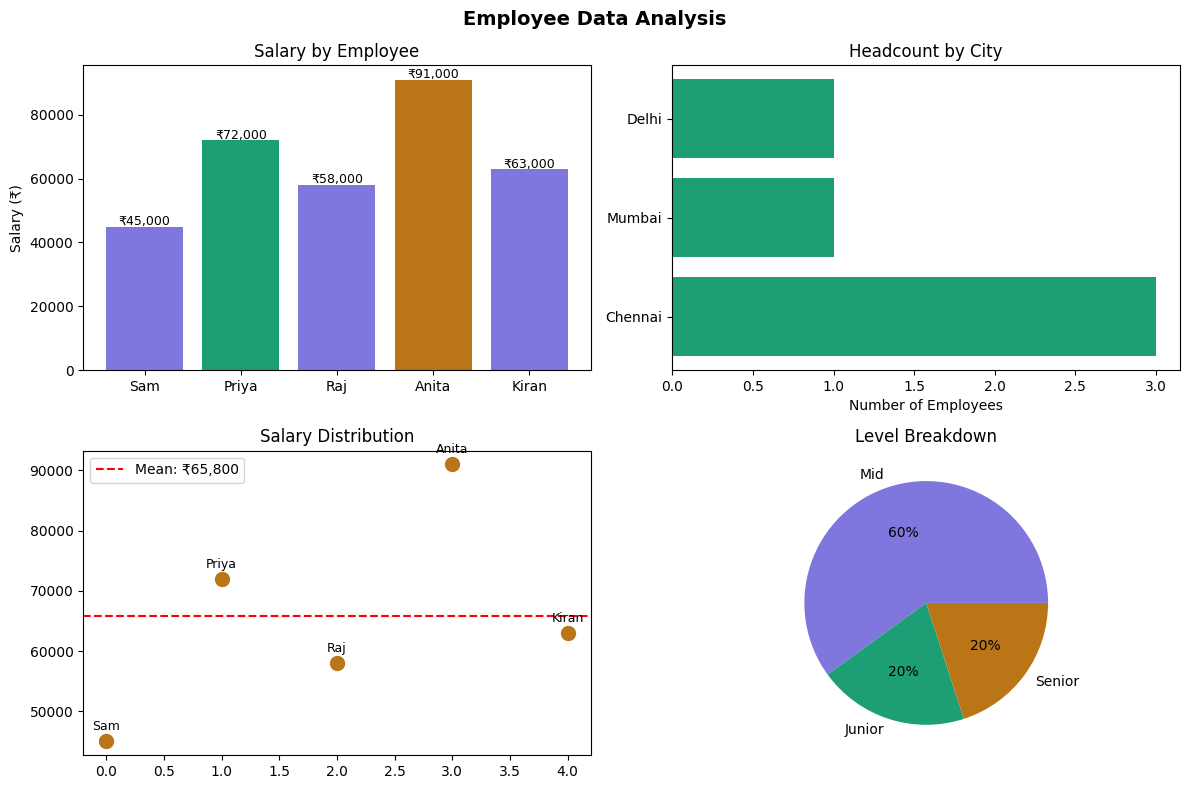

Chart saved as employee_analysis.png


In [10]:
# Day 3 - Matplotlib: Visualizing data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Your employee data
df = pd.DataFrame({
    "name":   ["Sam", "Priya", "Raj", "Anita", "Kiran"],
    "city":   ["Chennai", "Mumbai", "Chennai", "Delhi", "Chennai"],
    "salary": [45000, 72000, 58000, 91000, 63000],
    "level":  ["Junior", "Mid", "Mid", "Senior", "Mid"]
})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Employee Data Analysis", fontsize=14, fontweight="bold")

# Chart 1 — Bar chart: Salary by employee
axes[0,0].bar(df["name"], df["salary"], color=["#7F77DD","#1D9E75","#7F77DD","#BA7517","#7F77DD"])
axes[0,0].set_title("Salary by Employee")
axes[0,0].set_ylabel("Salary (₹)")
for i, v in enumerate(df["salary"]):
    axes[0,0].text(i, v + 500, f"₹{v:,}", ha="center", fontsize=9)

# Chart 2 — Horizontal bar: City headcount
city_counts = df["city"].value_counts()
axes[0,1].barh(city_counts.index, city_counts.values, color="#1D9E75")
axes[0,1].set_title("Headcount by City")
axes[0,1].set_xlabel("Number of Employees")

# Chart 3 — Scatter: just salary distribution
axes[1,0].scatter(range(len(df)), df["salary"], s=100, color="#BA7517", zorder=5)
axes[1,0].axhline(y=df["salary"].mean(), color="red", linestyle="--", label=f'Mean: ₹{df["salary"].mean():,.0f}')
for i, row in df.iterrows():
    axes[1,0].annotate(row["name"], (i, row["salary"]), textcoords="offset points", xytext=(0,8), ha="center", fontsize=9)
axes[1,0].set_title("Salary Distribution")
axes[1,0].legend()

# Chart 4 — Pie: Level breakdown
level_counts = df["level"].value_counts()
axes[1,1].pie(level_counts.values, labels=level_counts.index, autopct="%1.0f%%",
              colors=["#7F77DD", "#1D9E75", "#BA7517"])
axes[1,1].set_title("Level Breakdown")

plt.tight_layout()
plt.savefig("employee_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as employee_analysis.png")

Correlation matrix:
             salary  experience   age  performance  team_size
salary         1.00        0.96 -0.09        -0.10       0.08
experience     0.96        1.00 -0.08        -0.11       0.07
age           -0.09       -0.08  1.00         0.13      -0.09
performance   -0.10       -0.11  0.13         1.00      -0.00
team_size      0.08        0.07 -0.09        -0.00       1.00


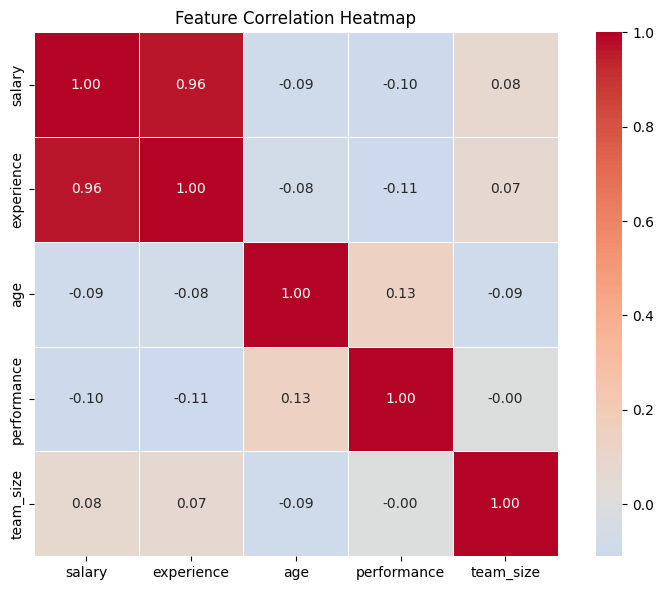

Heatmap saved


In [11]:
# Correlation heatmap — the first thing every DS/AI engineer looks at
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Bigger dataset for meaningful correlations
np.random.seed(42)
n = 100

df = pd.DataFrame({
    "salary":        np.random.randint(30000, 120000, n),
    "experience":    np.random.randint(1, 15, n),
    "age":           np.random.randint(22, 50, n),
    "performance":   np.random.randint(1, 10, n),
    "team_size":     np.random.randint(3, 20, n),
})

# Make salary correlate with experience realistically
df["salary"] = df["experience"] * 5000 + np.random.randint(20000, 40000, n)

# Correlation matrix — like running corr() in SQL but visual
corr = df.corr()

print("Correlation matrix:")
print(corr.round(2))

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Heatmap saved")